### Import the necessary libraries

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as s 5ns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, r2_score

### Load the dataset

In [66]:
car_df = pd.read_csv('car data.csv')
car_df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


### Statistical Summary of dataset

In [67]:
car_df.shape

(301, 9)

In [68]:
car_df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [69]:
car_df.describe(include = 'object')

,Car_Name,Fuel_Type,Seller_Type,Transmission
count,301,301,301,301
unique,98,3,2,2
top,city,Petrol,Dealer,Manual
freq,26,239,195,261


### Checking for missing values

In [70]:
car_df.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

### Exploratory Data Analysis

#### Checking the distribution of categorical columns

In [71]:
print(car_df.Fuel_Type.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64


In [72]:
print(car_df.Transmission.value_counts())

Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


In [73]:
print(car_df.Seller_Type.value_counts())

Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64


### Data Preprocessing

#### Dealing with the Categorical columns

In [74]:
# Encoding the following categorical columns -->  "seller_type", "fuel", "transmission", "owner"

# For the fuel column
car_df.replace({'Fuel_Type': {'Petrol': 0, 'Diesel': 1, 'CNG' : 2}}, inplace = True)

# For the transmission column
car_df.replace({'Transmission': {'Manual': 0, 'Automatic': 1}}, inplace = True)

# For the seller_type column
car_df.replace({'Seller_Type': {'Dealer': 0, 'Individual': 1}}, inplace = True)

# For the owner column
car_df.replace({'owner': {'First Owner': 0, 'Second Owner': 1, 'Third Owner' : 2, 'Fourth & Above Owner' : 3, 'Test Drive Car': 4}}, inplace = True)

C:\Users\Itz_Ebuka\AppData\Local\Temp\ipykernel_13080\739343396.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_df.replace({'Fuel_Type': {'Petrol': 0, 'Diesel': 1, 'CNG' : 2}}, inplace = True)
C:\Users\Itz_Ebuka\AppData\Local\Temp\ipykernel_13080\739343396.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_df.replace({'Transmission': {'Manual': 0, 'Automatic': 1}}, inplace = True)
C:\Users\Itz_Ebuka\AppData\Local\Temp\ipykernel_13080\739343396.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and w

In [75]:
car_df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


#### Removing the name column

In [76]:
car_df = car_df.drop('Car_Name', axis = 1)

In [77]:
car_df.shape

(301, 8)

### Splitting the dataset

In [78]:
X = car_df.drop('Selling_Price', axis = 1).values

y = car_df['Selling_Price'].values

In [88]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.1, random_state = 2)

### Scaling the numerical features

In [89]:
scaler = StandardScaler()

In [90]:
X_train_scaled = scaler.fit_transform(X_train)

In [91]:
X_val_scaled = scaler.transform(X_val)

In [92]:
X_train_scaled

array([[ 0.48477622, -0.37855906, -0.23844681, ..., -0.73081524,
        -0.39223227, -0.17474081],
       [ 0.82386839, -0.02276125, -0.51776898, ..., -0.73081524,
        -0.39223227, -0.17474081],
       [ 0.48477622,  0.6506731 , -0.39942472, ..., -0.73081524,
        -0.39223227, -0.17474081],
       ...,
       [-0.19340813,  1.21299078,  0.44782611, ..., -0.73081524,
        -0.39223227, -0.17474081],
       [ 0.82386839,  0.33528135,  0.12594457, ..., -0.73081524,
        -0.39223227, -0.17474081],
       [-0.19340813, -0.79384358, -0.64156005, ...,  1.36833491,
        -0.39223227, -0.17474081]])

In [93]:
X_val_scaled

array([[-1.21068465,  1.41951065,  0.29984627,  1.93348764, -0.73081524,
        -0.39223227, -0.17474081],
       [ 0.14568404, -0.78306863, -0.3692197 , -0.49461312,  1.36833491,
        -0.39223227, -0.17474081],
       [ 0.14568404, -0.11704206,  0.05166993, -0.49461312, -0.73081524,
        -0.39223227, -0.17474081],
       [-0.5325003 , -0.20458852,  0.33487914,  1.93348764, -0.73081524,
        -0.39223227, -0.17474081],
       [ 0.48477622,  0.78423758, -0.61927766, -0.49461312, -0.73081524,
         2.54950976, -0.17474081],
       [ 0.14568404, -0.15744812, -0.46825255, -0.49461312, -0.73081524,
        -0.39223227, -0.17474081],
       [-0.87159247, -0.00704778,  0.29920255,  4.36158839, -0.73081524,
        -0.39223227, -0.17474081],
       [ 0.48477622,  0.0906002 , -0.11101629,  1.93348764, -0.73081524,
        -0.39223227, -0.17474081],
       [-0.19340813, -0.82302574, -0.41873613, -0.49461312,  1.36833491,
        -0.39223227, -0.17474081],
       [ 0.48477622, -0.0104

### Building the Models

#### Using Linear Regression

In [94]:
# Create an instance of the Linear Regression model
lr_model = LinearRegression()

In [95]:
# Fit the model
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [96]:
# Make predictions on training data
training_pred = lr_model.predict(X_train_scaled)

In [97]:
# Evaluate the model performance
print('R Squared Error: ', r2_score(y_train, training_pred))

R Squared Error:  0.8799451660493707


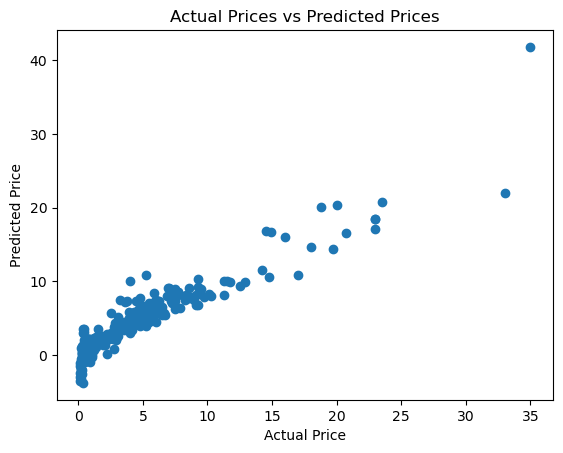

In [98]:
plt.scatter(y_train, training_pred)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual Prices vs Predicted Prices')
plt.show()

In [99]:
# Making predictions with the test data
testing_pred = lr_model.predict(X_val_scaled)

In [100]:
print('R Squared Error: ', r2_score(y_val, testing_pred))

R Squared Error:  0.8365766715024999


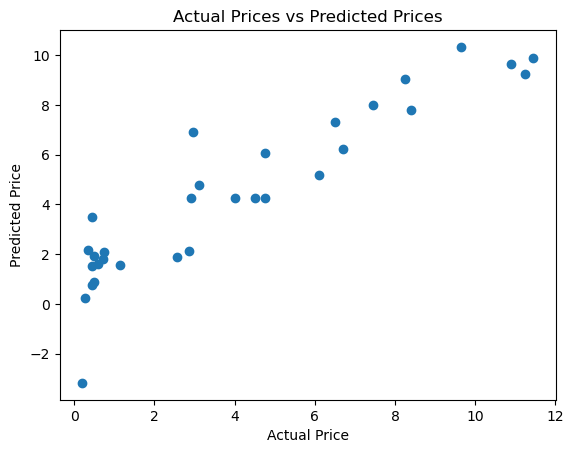

In [101]:
plt.scatter(y_val, testing_pred)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual Prices vs Predicted Prices')
plt.show()

The Linear Regression Model performs with a score of approx. 87.99% on the training set and 83.66% on the test set

#### Using Lasso Regression

In [102]:
lasso_reg = Lasso()

In [103]:
lasso_reg.fit(X_train_scaled, y_train)

Lasso()

In [104]:
lasso_training_pred = lasso_reg.predict(X_train_scaled)

In [105]:
print('R Squared Error: ', r2_score(y_train, lasso_training_pred))

R Squared Error:  0.7787347070040549


In [106]:
lasso_testing_pred = lasso_reg.predict(X_val_scaled)

In [107]:
print('R Squared Error: ', r2_score(y_val, lasso_testing_pred))

R Squared Error:  0.793812275043985


The Lasso Regression performs lesser with the 77.87% for the training set and 79.38% on the testing set.

### Conclusion

Both models performs well with the dataset but the Linear Regression model is a much better option to choose due to its higher score than the Lasso Regression model.